In [1]:
#imports and basic setup
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
from glob import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DATA_ROOT = "/workspace/ML Main Large/Processed data"  # ← your processed folder
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20

DEVICE: cuda


In [2]:
#2. dataset loader
class RoadDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.img_dir = os.path.join(root, split, "images")
        self.mask_dir = os.path.join(root, split, "masks")

        self.img_paths = sorted(glob(os.path.join(self.img_dir, "*")))
        self.mask_paths = sorted(glob(os.path.join(self.mask_dir, "*")))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype("float32")

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"].unsqueeze(0)

        return img, mask


train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

In [3]:
#UNet++ Architecture
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNetPlusPlus(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        nb = [32, 64, 128, 256, 512]

        self.conv0_0 = ConvBlock(3, nb[0])
        self.conv1_0 = ConvBlock(nb[0], nb[1])
        self.conv2_0 = ConvBlock(nb[1], nb[2])
        self.conv3_0 = ConvBlock(nb[2], nb[3])
        self.conv4_0 = ConvBlock(nb[3], nb[4])

        self.up1_0 = nn.ConvTranspose2d(nb[1], nb[0], 2, stride=2)
        self.up2_0 = nn.ConvTranspose2d(nb[2], nb[1], 2, stride=2)
        self.up3_0 = nn.ConvTranspose2d(nb[3], nb[2], 2, stride=2)
        self.up4_0 = nn.ConvTranspose2d(nb[4], nb[3], 2, stride=2)

        self.conv0_1 = ConvBlock(nb[0] + nb[0], nb[0])
        self.conv1_1 = ConvBlock(nb[1] + nb[1], nb[1])
        self.conv2_1 = ConvBlock(nb[2] + nb[2], nb[2])
        self.conv3_1 = ConvBlock(nb[3] + nb[3], nb[3])

        self.final = nn.Conv2d(nb[0], n_classes, 1)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(F.max_pool2d(x0_0, 2))
        x2_0 = self.conv2_0(F.max_pool2d(x1_0, 2))
        x3_0 = self.conv3_0(F.max_pool2d(x2_0, 2))
        x4_0 = self.conv4_0(F.max_pool2d(x3_0, 2))

        x3_1 = self.conv3_1(torch.cat([x3_0, self.up4_0(x4_0)], 1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up3_0(x3_1)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up2_0(x2_1)], 1))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up1_0(x1_1)], 1))

        return self.final(x0_1)

In [4]:
#  Losses
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2 * inter + smooth) / (union + smooth)

bce = nn.BCEWithLogitsLoss()

def total_loss(pred, target):
    return 0.5 * bce(pred, target) + 0.5 * dice_loss(pred, target)


def iou(pred, mask):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * mask).sum()
    union = pred.sum() + mask.sum() - inter
    return (inter + 1e-6) / (union + 1e-6)

In [5]:
train_ds = RoadDataset(DATA_ROOT, "train", train_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print("Train samples:", len(train_ds))

Train samples: 14688


In [6]:
#Training function
def train_model():
    model = UNetPlusPlus().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    best_loss = float("inf")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        t_loss = 0
        t_iou = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

        for img, mask in pbar:
            img, mask = img.to(DEVICE), mask.to(DEVICE)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                pred = model(img)
                loss = total_loss(pred, mask)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            t_loss += loss.item()
            t_iou += iou(pred, mask).item()

            pbar.set_postfix({
       
                "loss": t_loss / len(train_loader),
                "iou": t_iou / len(train_loader)
            })

        avg_loss = t_loss / len(train_loader)
        avg_iou  = t_iou / len(train_loader)

        print(f"✔ Train Loss: {avg_loss:.4f} | Train IoU: {avg_iou:.4f}")

        # save best
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "unetplusplus_best.pth")
            print("Saved BEST model!")

    print("Training complete.")

In [7]:
train_model()


poch 1/20: 100%|██████████| 3672/3672 [00:53<00:00, 69.20it/s, loss=0.449, iou=0.347]   

✔ Train Loss: 0.4489 | Train IoU: 0.3471
Saved BEST model!



poch 2/20: 100%|██████████| 3672/3672 [00:52<00:00, 69.91it/s, loss=0.252, iou=0.434]   

✔ Train Loss: 0.2520 | Train IoU: 0.4344
Saved BEST model!



poch 3/20: 100%|██████████| 3672/3672 [00:52<00:00, 69.69it/s, loss=0.234, iou=0.455]   

...

✔ Train Loss: 0.1983 | Train IoU: 0.5153
Saved BEST model!



poch 19/20: 100%|██████████| 3672/3672 [00:52<00:00, 69.74it/s, loss=0.197, iou=0.518]   

✔ Train Loss: 0.1968 | Train IoU: 0.5184
Saved BEST model!



poch 20/20: 100%|██████████| 3672/3672 [00:52<00:00, 69.86it/s, loss=0.195, iou=0.522]   

✔ Train Loss: 0.1948 | Train IoU: 0.5217
Saved BEST model!
Training complete.


In [16]:
#INFERENCE CODE (Works for TEST)

#Load trained model
model = UNetPlusPlus().to(DEVICE)
model.load_state_dict(torch.load("unetplusplus_best.pth", map_location=DEVICE))
model.eval()

print("Model loaded for inference.")

Model loaded for inference.


In [9]:
#Prediction function
def predict_mask(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    tensor = valid_transform(image=img_resized)["image"]
    tensor = tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor)
        pred = torch.sigmoid(pred)[0, 0].cpu().numpy()

    mask = (pred > 0.5).astype(np.uint8) * 255
    mask = cv2.resize(mask, (w, h))

    return img, mask

In [12]:
# Save predictions for TEST split
TEST_DIR = f"{DATA_ROOT}/test/images"
SAVE_DIR = "test_predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

# Get only valid image files
valid_ext = (".jpg", ".jpeg", ".png")
files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(valid_ext)
])

print(f"Found {len(files)} valid images to predict.")

for f in files:
    img_path = os.path.join(TEST_DIR, f)

    # Generate prediction
    try:
        img, mask = predict_mask(img_path)
    except Exception as e:
        print(f"⚠ Skipping invalid file: {f} | Error: {e}")
        continue

    # Save predicted mask
    out_name = os.path.splitext(f)[0] + "_mask.png"
    save_path = os.path.join(SAVE_DIR, out_name)
    cv2.imwrite(save_path, mask)

print("Test predictions saved in 'test_predictionsUnet++/'")

Found 13082 valid images to predict.
Test predictions saved in 'test_predictionsUnet++/'


In [13]:
#This function takes an image path → predicts → overlays mask → returns final blended output.
import cv2
import numpy as np
import matplotlib.pyplot as plt

def overlay_prediction(img, mask, alpha=0.5):
    """
    img: RGB image (H, W, 3)
    mask: predicted binary mask (H, W)
    alpha: transparency
    """

    mask_color = np.zeros_like(img)
    mask_color[:, :, 0] = 255  # Red overlay

    mask_bin = (mask > 0).astype("uint8")
    mask_color = mask_color * mask_bin[:, :, None]

    overlay = cv2.addWeighted(img, 1, mask_color, alpha, 0)
    return overlay

In [14]:
#Visualize Original, Mask & Overlay (side-by-side)
def visualize_prediction(img_path):
    img, pred_mask = predict_mask(img_path)

    overlay = overlay_prediction(img, pred_mask)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

Found 13082 valid test images
Showing: 15607_sat.jpg


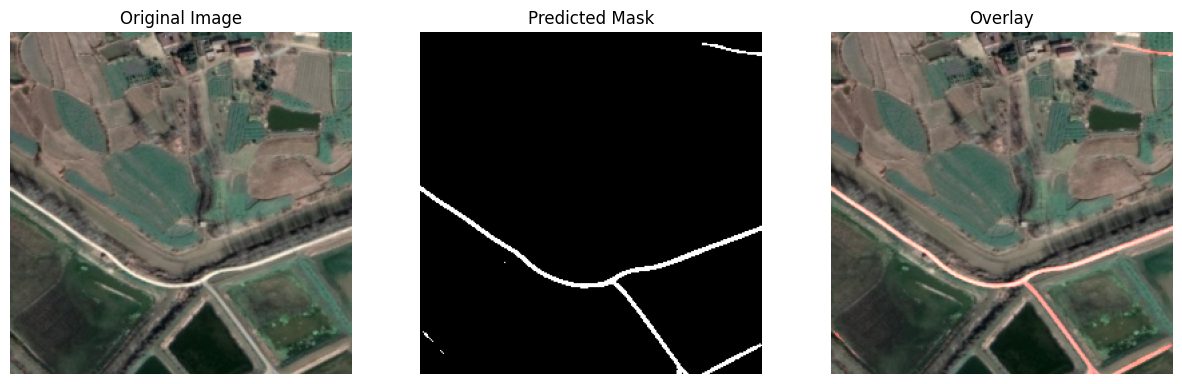

Showing: 15608_sat.jpg


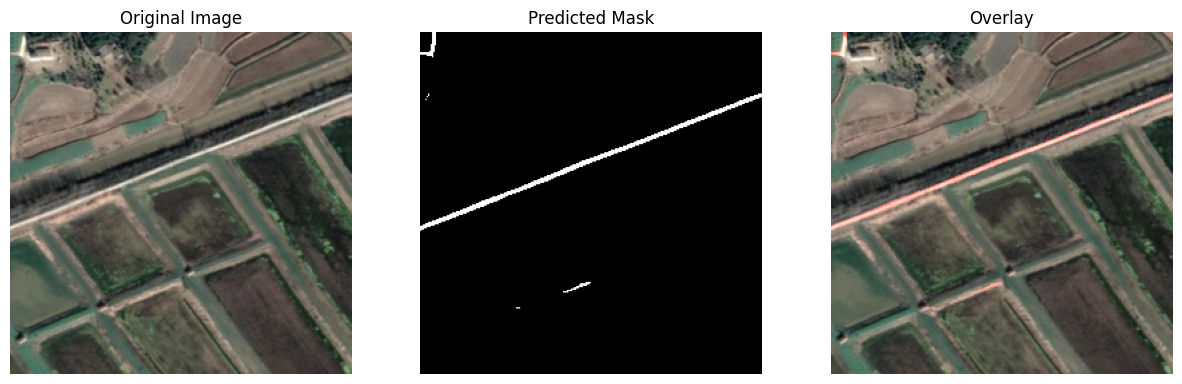

Showing: 15609_sat.jpg


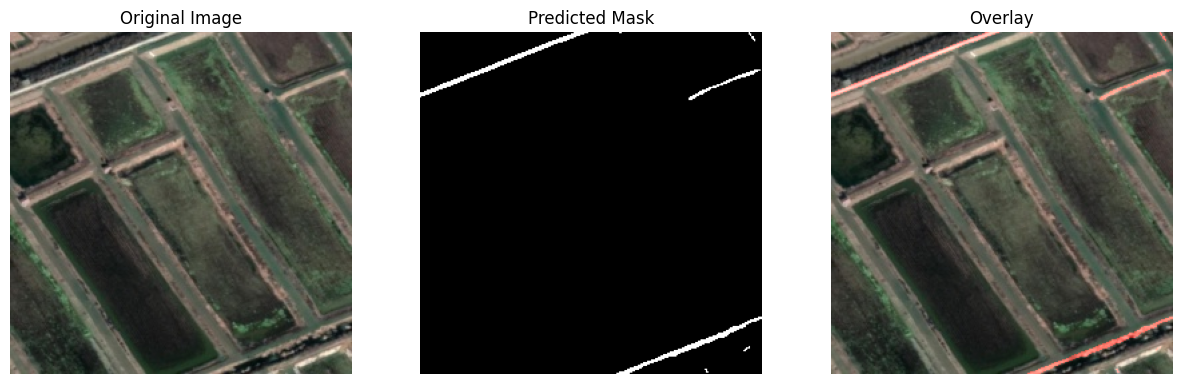

Showing: 15612_sat.jpg


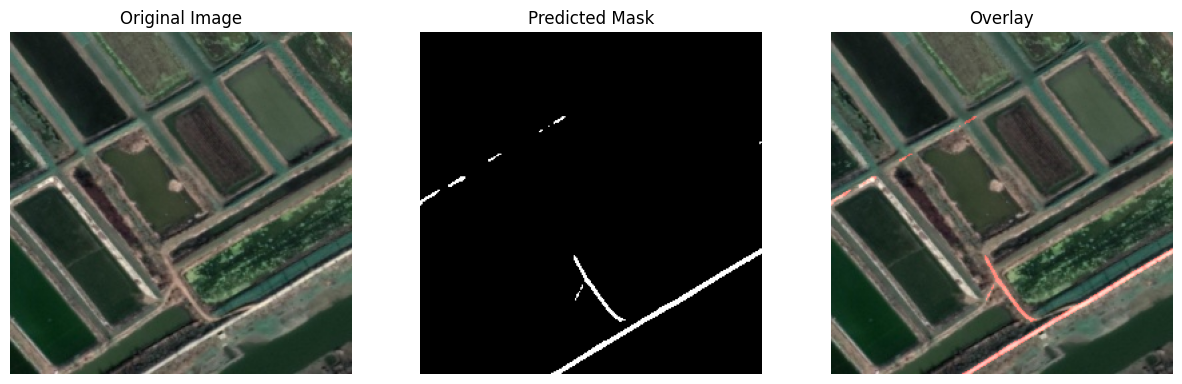

Showing: 15613_sat.jpg


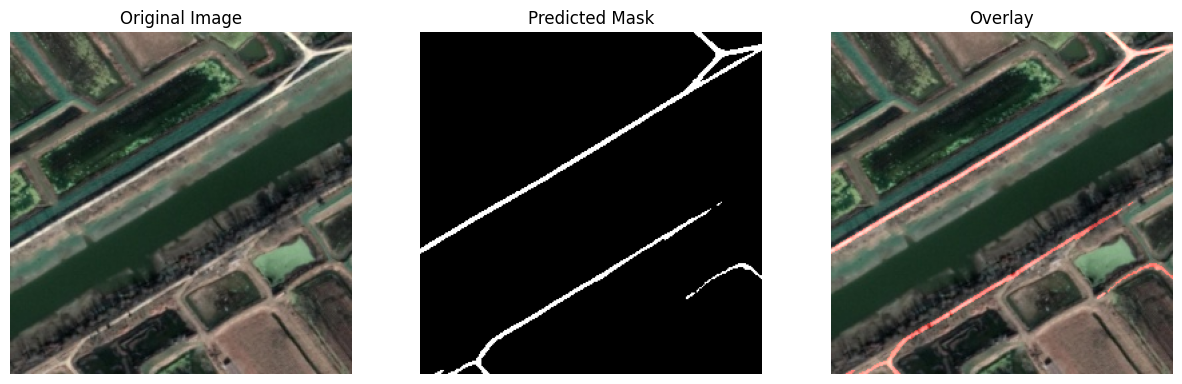

In [15]:
# Filter only actual image files
valid_ext = (".jpg", ".jpeg", ".png")

test_images = [
    f for f in sorted(os.listdir(TEST_DIR))
    if f.lower().endswith(valid_ext)
]

print("Found", len(test_images), "valid test images")

# Show first 5 valid predictions
for f in test_images[:5]:
    print("Showing:", f)
    visualize_prediction(os.path.join(TEST_DIR, f))

In [23]:
def evaluate_saved_model(model_path, dataset, batch_size=4):

    print("\nLoading saved model from:", model_path)

    # load model
    model = UNetPlusPlus().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    def compute_loss(pred, target):
        return 0.5 * bce(pred, target) + 0.5 * dice_loss(pred, target)

    total_loss_value = 0
    total_iou_value = 0
    count = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = model(imgs)

            # compute model loss for this batch
            loss_value = compute_loss(preds, masks)
            total_loss_value += loss_value.item()

            # compute IoU
            batch_iou = iou(preds, masks)
            total_iou_value += batch_iou.item()
            count += 1

    avg_loss = total_loss_value / count
    avg_iou = total_iou_value / count

    print(f"\nFINAL EVALUATION:")
    print(f"Avg Loss = {avg_loss:.4f}")
    print(f"Avg IoU  = {avg_iou:.4f}")

    return avg_loss, avg_iou

In [24]:
val_ds = RoadDataset(DATA_ROOT, "train", valid_transform)

evaluate_saved_model("unetplusplus_best.pth", val_ds)


Loading saved model from: unetplusplus_best.pth


Evaluating: 100%|██████████| 3672/3672 [04:16<00:00, 14.33it/s]


FINAL EVALUATION:
Avg Loss = 0.1965
Avg IoU  = 0.5282


(0.1964688281151253, 0.5282058856502868)